# DINOv3 crop linear probe

使用 `data/dataset/metadata.csv` 与已存盘 crop 图像快速验证：DINOv3 冻结特征 + 线性分类头在 train/val/test 三分割上的可靠性。

特点：
- 直接读取 stage 14 生成的 `data/dataset/images/*`，不再从原图 bbox 在线裁剪。
- 读取正式 pipeline 的 dataset 根目录与 DINOv3 模型名，但 notebook 内部自包含数据集、collator 与线性头，避免旧 stage 接口漂移。
- 按正式 trainer 的输入处理方式显式 resize/crop，本实验默认使用 384。
- 特征使用更稳的 `CLS + mean(token)`，避免 max pooling 被边缘极端 patch 带跑。
- 增加两个 inference-time confusion group fallback：`113/115/415 -> jnr_suburban_standard`，`183/485 -> jnr_limited_express_standard`。
- 学习率保持固定，用 validation loss 早停，最后在 test split 上评估。


In [1]:
from pathlib import Path
import os
import sys
import time

import numpy as np
import pandas as pd
import torch
from PIL import Image
from tqdm.auto import tqdm
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from transformers import AutoImageProcessor, AutoModel
from huggingface_hub import login


def find_project_root(start: Path | None = None) -> Path:
    start = (start or Path.cwd()).resolve()
    candidates = [start, *start.parents]
    for path in candidates:
        if (path / "pyproject.toml").exists() and (path / "pipeline").exists():
            return path
    raise RuntimeError(f"Cannot find wakareeru project root from {start}")


PROJECT_ROOT = find_project_root()
for path in [PROJECT_ROOT, PROJECT_ROOT / "pipeline"]:
    path_str = str(path)
    if path_str not in sys.path:
        sys.path.insert(0, path_str)

import utils


def get_torch_device(device_name: str = "auto") -> torch.device:
    if device_name == "auto":
        if torch.backends.mps.is_available():
            return torch.device("mps")
        if torch.cuda.is_available():
            return torch.device("cuda")
        return torch.device("cpu")
    return torch.device(device_name)


def validate_vit_image_size(image_size: int) -> int:
    image_size = int(image_size)
    if image_size < 1:
        raise ValueError("IMAGE_SIZE must be positive")
    if image_size % 16 != 0:
        print(f"warning: IMAGE_SIZE={image_size} is not divisible by 16")
    return image_size


tqdm.pandas()

config = utils.load_pipeline_config(PROJECT_ROOT / "config" / "pipeline_config.yaml")
data_root = utils.get_data_root(config)
dataset_root = utils.join_data_root(config["path"]["dataset_dir"], config=config)
metadata_path = dataset_root / config["trainer"]["metadata_file_name"]
labels_path = dataset_root / config["trainer"]["labels_file_name"]

print(f"project_root={PROJECT_ROOT}")
print(f"dataset_root={dataset_root}")


project_root=/Users/yukun/projects/wakareeru
dataset_root=/Users/yukun/projects/wakareeru/data/dataset


In [2]:
# 实验参数。先保持小而直接，便于快速判断数据可靠性。
SEED = 42
LABEL_COLUMN = config["trainer"]["label_id_column"]
LABEL_NAME_COLUMN = "label"
MIN_SAMPLES_PER_CLASS = 3
VAL_RATIO = 0.15
TEST_RATIO = 0.15

IMAGE_SIZE = validate_vit_image_size(384)
FEATURE_POOLING = "cls_mean"
FEATURE_BATCH_SIZE = int(config["trainer"]["batch_size"])
HEAD_BATCH_SIZE = int(config["trainer"]["batch_size"])
# Notebook 中自定义 Dataset 定义在 __main__，macOS/Python 3.12 的 spawn 多进程
# 无法稳定 pickle；这里固定为 0，避免 DataLoader worker 导入失败。
NUM_WORKERS = 0

MAX_EPOCHS = 100
PATIENCE = 10
MIN_DELTA = 1e-4

LR = float(config["trainer"]["phases"][0]["learning_rate"])
WEIGHT_DECAY = float(config["trainer"]["phases"][0]["weight_decay"])
HF_MODEL_NAME = config["trainer"]["backbone_model_name"]
DEVICE = get_torch_device(config["trainer"]["device"])

CONFIDENCE_FALLBACK_THRESHOLD = 0.55
CONFIDENCE_ABSTAIN_THRESHOLD = 0.35
CONFUSION_GROUPS = {
    "jnr_suburban_standard": ["113系", "113/115系", "115系", "165系", "415系", "455系"],
    "jnr_limited_express_standard": ["183系", "189系", "485系", "489系"],
    "jnr_kiha_standard": ["キハ40系", "キハ40/41系", "キハ47/48系", "キハ58系"],
}

feature_cache_dir = utils.join_data_root(
    config["trainer"]["feature_cache_dir"],
    config=config,
)
feature_cache_path = feature_cache_dir / f"dataset_crop_dinov3_{FEATURE_POOLING}_{IMAGE_SIZE}_features.pt"

rng = np.random.default_rng(SEED)
torch.manual_seed(SEED)
np.random.seed(SEED)

print(HF_MODEL_NAME, IMAGE_SIZE, FEATURE_POOLING, FEATURE_BATCH_SIZE, HEAD_BATCH_SIZE, LR, WEIGHT_DECAY, DEVICE)


facebook/dinov3-vits16-pretrain-lvd1689m 384 cls_mean 32 32 0.001 0.0001 mps


In [3]:
# 先看当前 dataset 的 label 分布，确认类别数量和长尾情况。
metadata_preview = pd.read_csv(metadata_path)
labels_preview = pd.read_csv(labels_path)
metadata_preview[LABEL_COLUMN] = metadata_preview[LABEL_COLUMN].astype(int)
metadata_preview = metadata_preview.merge(
    labels_preview[["label_id", "label"]],
    left_on=LABEL_COLUMN,
    right_on="label_id",
    how="left",
    suffixes=("", "_from_labels"),
)
metadata_preview[LABEL_NAME_COLUMN] = metadata_preview[LABEL_NAME_COLUMN].fillna(
    metadata_preview["label_from_labels"]
).astype(str)

label_counts = metadata_preview[LABEL_NAME_COLUMN].value_counts().rename_axis(LABEL_NAME_COLUMN).reset_index(name="count")
num_labels = len(label_counts)
num_samples = len(metadata_preview)
num_too_small = int((label_counts["count"] < MIN_SAMPLES_PER_CLASS).sum())

print(f"samples={num_samples}, labels={num_labels}, labels_below_min_samples={num_too_small}")
display(label_counts)


samples=18021, labels=186, labels_below_min_samples=5


,label,count
0,113/115系,1260
1,103系,845
2,D51形,752
3,485系,697
4,205系,586
...,...,...
181,ED77形,2
182,DB500形,2
183,DD19形,2
184,489系,2


## 读取 metadata 并做三分割

`MIN_SAMPLES_PER_CLASS=3` 是为了让每个类别至少能落入 train/val/test。样本太少的类先过滤掉，否则 stratified split 本身不可靠。

In [4]:
metadata = pd.read_csv(metadata_path)
labels_table = pd.read_csv(labels_path)
metadata["abs_image_path"] = metadata["image_path"].map(lambda p: dataset_root / str(p))
metadata["crop_id"] = metadata["image_path"].str.extract(r"_(\d+)\.").astype(int)
metadata[LABEL_COLUMN] = metadata[LABEL_COLUMN].astype(int)

label_lookup = labels_table.set_index("label_id")["label"].astype(str).to_dict()
metadata[LABEL_NAME_COLUMN] = metadata[LABEL_COLUMN].map(label_lookup).fillna(metadata.get("label", "")).astype(str)

exists_mask = metadata["abs_image_path"].progress_map(Path.exists)
if not exists_mask.all():
    print(f"missing image files: {(~exists_mask).sum()}")
metadata = metadata.loc[exists_mask].copy().reset_index(drop=True)

class_counts = metadata[LABEL_COLUMN].value_counts()
kept_label_ids = class_counts[class_counts >= MIN_SAMPLES_PER_CLASS].index
kept_label_ids = sorted(int(label_id) for label_id in kept_label_ids)
df = metadata[metadata[LABEL_COLUMN].isin(kept_label_ids)].copy().reset_index(drop=True)

# 重新压缩 label id，避免过滤长尾类后 CrossEntropy 类别 id 不连续。
label_to_id = {label_lookup[label_id]: idx for idx, label_id in enumerate(kept_label_ids)}
raw_label_id_to_exp_id = {label_id: idx for idx, label_id in enumerate(kept_label_ids)}
id_to_label = {idx: label_lookup[label_id] for idx, label_id in enumerate(kept_label_ids)}
df["label_id_exp"] = df[LABEL_COLUMN].map(raw_label_id_to_exp_id).astype(int)

def confusion_group_for_label(label: str) -> str | None:
    label = str(label)
    for group_name, members in CONFUSION_GROUPS.items():
        if any(member in label for member in members):
            return group_name
    return None


df["confusion_group"] = df[LABEL_NAME_COLUMN].map(confusion_group_for_label)

train_val_df, test_df = train_test_split(
    df,
    test_size=TEST_RATIO,
    random_state=SEED,
    stratify=df["label_id_exp"],
)
relative_val_ratio = VAL_RATIO / (1.0 - TEST_RATIO)
train_df, val_df = train_test_split(
    train_val_df,
    test_size=relative_val_ratio,
    random_state=SEED,
    stratify=train_val_df["label_id_exp"],
)

split_frames = {
    "train": train_df.reset_index(drop=True),
    "val": val_df.reset_index(drop=True),
    "test": test_df.reset_index(drop=True),
}
for split, part in tqdm(split_frames.items(), desc="split summary"):
    print(split, part.shape, "classes=", part[LABEL_NAME_COLUMN].nunique())

print("confusion group support:")
display(df["confusion_group"].fillna("other").value_counts().rename("count").to_frame())
display(df[LABEL_NAME_COLUMN].value_counts().rename("count").to_frame().head(30))


  0%|          | 0/18021 [00:00<?, ?it/s]

split summary:   0%|          | 0/3 [00:00<?, ?it/s]

train (12608, 18) classes= 181
val (2702, 18) classes= 175
test (2702, 18) classes= 177
confusion group support:


,count
confusion_group,
other,13833
jnr_suburban_standard,1679
jnr_kiha_standard,1367
jnr_limited_express_standard,1133


,count
label,
113/115系,1260
103系,845
D51形,752
485系,697
205系,586
キハ58系,456
201系,433
E3系,414
EF65形,412


## DINOv3 特征抽取

如果 `feature_cache_path` 已存在，默认直接加载；想重抽特征时把 `REBUILD_FEATURE_CACHE=True`。

In [5]:
class StoredCropDataset(torch.utils.data.Dataset):
    def __init__(self, frame: pd.DataFrame):
        self.frame = frame.reset_index(drop=True)

    def __len__(self):
        return len(self.frame)

    def __getitem__(self, idx):
        row = self.frame.iloc[idx]
        with Image.open(row["abs_image_path"]) as image:
            image = image.convert("RGB")
            image.load()
            return {
                "image": image.copy(),
                "crop_id": int(row["crop_id"]),
                "label_id": int(row["label_id_exp"]),
                "split": row["split"],
            }


class StoredCropCollator:
    def __init__(self, processor, image_size: int):
        self.processor = processor
        self.image_size = int(image_size)

    def __call__(self, batch):
        processor_kwargs = {
            "images": [item["image"] for item in batch],
            "return_tensors": "pt",
            "size": {
                "height": self.image_size,
                "width": self.image_size,
            },
        }
        if getattr(self.processor, "crop_size", None) is not None:
            processor_kwargs["crop_size"] = {
                "height": self.image_size,
                "width": self.image_size,
            }
        encoded = self.processor(**processor_kwargs)
        return {
            "pixel_values": encoded["pixel_values"],
            "labels": torch.tensor([item["label_id"] for item in batch], dtype=torch.long),
            "crop_ids": torch.tensor([item["crop_id"] for item in batch], dtype=torch.long),
        }


def cls_mean_features(outputs) -> torch.Tensor:
    hidden = outputs.last_hidden_state
    if getattr(outputs, "pooler_output", None) is not None:
        cls_feature = outputs.pooler_output
    else:
        cls_feature = hidden[:, 0]
    patch_tokens = hidden[:, 1:]
    mean_feature = patch_tokens.mean(dim=1)
    return torch.cat([cls_feature, mean_feature], dim=1)


def extract_features(frame: pd.DataFrame, processor, model, batch_size: int, device: torch.device):
    dataset = StoredCropDataset(frame)
    loader = torch.utils.data.DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=NUM_WORKERS,
        collate_fn=StoredCropCollator(processor, IMAGE_SIZE),
    )
    features, labels_out, crop_ids = [], [], []
    model.eval()
    with torch.inference_mode():
        for batch in tqdm(loader, desc="DINOv3 features"):
            pixel_values = batch["pixel_values"].to(device)
            outputs = model(pixel_values=pixel_values)
            features.append(cls_mean_features(outputs).detach().float().cpu())
            labels_out.append(batch["labels"].cpu())
            crop_ids.append(batch["crop_ids"].cpu())
    return {
        "features": torch.cat(features, dim=0),
        "labels": torch.cat(labels_out, dim=0),
        "crop_ids": torch.cat(crop_ids, dim=0),
    }


In [6]:
REBUILD_FEATURE_CACHE = False

split_df = pd.concat(
    [part.assign(split=split) for split, part in split_frames.items()],
    ignore_index=True,
)


def feature_cache_matches(cache: dict) -> bool:
    return (
        cache.get("model_name") == HF_MODEL_NAME
        and int(cache.get("image_size", -1)) == IMAGE_SIZE
        and cache.get("feature_pooling") == FEATURE_POOLING
        and cache.get("label_to_id") == label_to_id
    )


def derive_cls_mean_cache_from_cls_mean_max() -> dict | None:
    source_path = feature_cache_dir / f"dataset_crop_dinov3_cls_mean_max_{IMAGE_SIZE}_features.pt"
    if not source_path.exists():
        return None
    source = torch.load(source_path, map_location="cpu", weights_only=False)
    if (
        source.get("model_name") != HF_MODEL_NAME
        or int(source.get("image_size", -1)) != IMAGE_SIZE
        or source.get("feature_pooling") != "cls_mean_max"
        or source.get("label_to_id") != label_to_id
    ):
        return None
    source_features = source["features"]
    if source_features.shape[1] % 3 != 0:
        raise ValueError(f"cls_mean_max缓存维度不符合[CLS, mean, max]拼接: {source_features.shape}")
    hidden_size = source_features.shape[1] // 3
    expected_crop_ids = split_df["crop_id"].astype(int).tolist()
    source_crop_ids = source["crop_ids"].cpu().numpy().astype(int).tolist()
    if source_crop_ids != expected_crop_ids:
        raise ValueError("cls_mean_max缓存的crop顺序与当前split_df不一致，不能直接派生cls_mean。")
    derived = dict(source)
    derived["features"] = source_features[:, : hidden_size * 2].contiguous()
    derived["feature_pooling"] = FEATURE_POOLING
    derived["derived_from"] = str(source_path)
    derived["created_at"] = time.strftime("%Y-%m-%d %H:%M:%S")
    return derived


if feature_cache_path.exists() and not REBUILD_FEATURE_CACHE:
    feature_cache = torch.load(feature_cache_path, map_location="cpu", weights_only=False)
    if not feature_cache_matches(feature_cache):
        raise ValueError("feature cache metadata does not match this notebook configuration; set REBUILD_FEATURE_CACHE=True")
    print(f"loaded feature cache: {feature_cache_path}")
elif not REBUILD_FEATURE_CACHE:
    feature_cache = derive_cls_mean_cache_from_cls_mean_max()
    if feature_cache is None:
        raise FileNotFoundError(
            f"没有找到可复用的{FEATURE_POOLING}缓存，也无法从cls_mean_max缓存派生。"
            "请设置REBUILD_FEATURE_CACHE=True重抽特征。"
        )
    feature_cache_dir.mkdir(parents=True, exist_ok=True)
    torch.save(feature_cache, feature_cache_path)
    print(f"derived cls_mean feature cache from cls_mean_max: {feature_cache_path}")
else:
    token = os.getenv("HF_TOKEN")
    if token:
        login(token=token)
    processor = AutoImageProcessor.from_pretrained(HF_MODEL_NAME)
    model = AutoModel.from_pretrained(HF_MODEL_NAME).to(DEVICE)
    feature_parts = []
    for split in tqdm(["train", "val", "test"], desc="feature splits"):
        part = split_df[split_df["split"] == split].reset_index(drop=True)
        extracted = extract_features(part, processor, model, FEATURE_BATCH_SIZE, DEVICE)
        extracted["splits"] = [split] * len(part)
        feature_parts.append(extracted)
    feature_cache = {
        "features": torch.cat([p["features"] for p in feature_parts], dim=0),
        "labels": torch.cat([p["labels"] for p in feature_parts], dim=0),
        "crop_ids": torch.cat([p["crop_ids"] for p in feature_parts], dim=0),
        "splits": sum([p["splits"] for p in feature_parts], []),
        "label_to_id": label_to_id,
        "id_to_label": id_to_label,
        "raw_label_id_to_exp_id": raw_label_id_to_exp_id,
        "model_name": HF_MODEL_NAME,
        "image_size": IMAGE_SIZE,
        "feature_pooling": FEATURE_POOLING,
        "created_at": time.strftime("%Y-%m-%d %H:%M:%S"),
    }
    feature_cache_dir.mkdir(parents=True, exist_ok=True)
    torch.save(feature_cache, feature_cache_path)
    print(f"saved feature cache: {feature_cache_path}")

print(feature_cache["features"].shape, len(feature_cache["label_to_id"]))


loaded feature cache: /Users/yukun/projects/wakareeru/data/trainer_feature_cache/dataset_crop_dinov3_cls_mean_384_features.pt
torch.Size([18012, 768]) 181


## 固定学习率训练线性头 + 早停

In [7]:
class LinearHead(torch.nn.Module):
    def __init__(self, input_dim: int, num_classes: int):
        super().__init__()
        self.linear = torch.nn.Linear(input_dim, num_classes)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.linear(x)


class FeatureSplitDataset(torch.utils.data.Dataset):
    def __init__(self, feature_cache: dict, split: str):
        split_mask = np.array(feature_cache["splits"]) == split
        self.features = feature_cache["features"][split_mask].float()
        self.labels = feature_cache["labels"][split_mask].long()
        self.crop_ids = feature_cache["crop_ids"][split_mask].long()

    def __len__(self):
        return len(self.features)

    def __getitem__(self, idx):
        return self.features[idx], self.labels[idx], self.crop_ids[idx]


def evaluate_head(head, loader, criterion, device, desc="evaluate"):
    head.eval()
    losses, preds, labels, crop_ids, confidences = [], [], [], [], []
    top2_preds, top2_confidences = [], []
    with torch.inference_mode():
        for x_cpu, y_cpu, crop_ids_cpu in tqdm(loader, desc=desc, leave=False):
            x = x_cpu.to(device)
            y = y_cpu.to(device)
            logits = head(x)
            per_sample_loss = torch.nn.functional.cross_entropy(logits, y, reduction="none")
            prob = torch.softmax(logits, dim=1)
            confidence, pred = prob.max(dim=1)
            top2 = prob.topk(k=min(2, prob.shape[1]), dim=1)
            losses.append(per_sample_loss.detach().cpu())
            preds.append(pred.detach().cpu())
            labels.append(y_cpu.cpu())
            crop_ids.append(crop_ids_cpu.cpu())
            confidences.append(confidence.detach().cpu())
            top2_preds.append(top2.indices.detach().cpu())
            top2_confidences.append(top2.values.detach().cpu())
    sample_losses = torch.cat(losses).numpy()
    preds = torch.cat(preds).numpy()
    labels = torch.cat(labels).numpy()
    crop_ids = torch.cat(crop_ids).numpy()
    confidences = torch.cat(confidences).numpy()
    top2_preds = torch.cat(top2_preds).numpy()
    top2_confidences = torch.cat(top2_confidences).numpy()
    return {
        "loss": float(sample_losses.mean()),
        "accuracy": float(accuracy_score(labels, preds)),
        "sample_loss": sample_losses,
        "confidence": confidences,
        "preds": preds,
        "labels": labels,
        "crop_ids": crop_ids,
        "top2_preds": top2_preds,
        "top2_confidence": top2_confidences,
    }


train_ds = FeatureSplitDataset(feature_cache, "train")
val_ds = FeatureSplitDataset(feature_cache, "val")
test_ds = FeatureSplitDataset(feature_cache, "test")

train_loader = torch.utils.data.DataLoader(train_ds, batch_size=HEAD_BATCH_SIZE, shuffle=True)
val_loader = torch.utils.data.DataLoader(val_ds, batch_size=HEAD_BATCH_SIZE, shuffle=False)
test_loader = torch.utils.data.DataLoader(test_ds, batch_size=HEAD_BATCH_SIZE, shuffle=False)

head_device = DEVICE
head = LinearHead(
    input_dim=int(feature_cache["features"].shape[1]),
    num_classes=len(feature_cache["label_to_id"]),
).to(head_device)
optimizer = torch.optim.AdamW(head.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
criterion = torch.nn.CrossEntropyLoss()

best_val_loss = float("inf")
best_state = None
bad_epochs = 0
history = []

for epoch in tqdm(range(MAX_EPOCHS), desc="cls-mean linear head"):
    head.train()
    running_loss = 0.0
    running_correct = 0
    running_n = 0
    for x_cpu, y_cpu, _ in tqdm(train_loader, desc=f"epoch {epoch} train", leave=False):
        x = x_cpu.to(head_device)
        y = y_cpu.to(head_device)
        optimizer.zero_grad(set_to_none=True)
        logits = head(x)
        loss = criterion(logits, y)
        loss.backward()
        optimizer.step()

        running_loss += float(loss.detach().cpu()) * int(y.numel())
        running_correct += int(logits.argmax(dim=1).eq(y).sum().detach().cpu())
        running_n += int(y.numel())

    train_loss = running_loss / max(1, running_n)
    train_acc = running_correct / max(1, running_n)
    val_metrics = evaluate_head(head, val_loader, criterion, head_device, desc=f"epoch {epoch} val")
    row = {
        "epoch": epoch,
        "train_loss": train_loss,
        "train_accuracy": train_acc,
        "val_loss": val_metrics["loss"],
        "val_accuracy": val_metrics["accuracy"],
        "lr": optimizer.param_groups[0]["lr"],
    }
    history.append(row)
    print(row)

    if val_metrics["loss"] < best_val_loss - MIN_DELTA:
        best_val_loss = val_metrics["loss"]
        best_state = {k: v.detach().cpu().clone() for k, v in head.state_dict().items()}
        bad_epochs = 0
    else:
        bad_epochs += 1
        if bad_epochs >= PATIENCE:
            print(f"early stopping at epoch={epoch}, best_val_loss={best_val_loss:.4f}")
            break

history_df = pd.DataFrame(history)
if best_state is not None:
    head.load_state_dict(best_state)
display(history_df.tail())


cls-mean linear head:   0%|          | 0/100 [00:00<?, ?it/s]

epoch 0 train:   0%|          | 0/394 [00:00<?, ?it/s]

epoch 0 val:   0%|          | 0/85 [00:00<?, ?it/s]

{'epoch': 0, 'train_loss': 2.734974794581457, 'train_accuracy': 0.43837246192893403, 'val_loss': 1.8592911958694458, 'val_accuracy': 0.6239822353811991, 'lr': 0.001}


epoch 1 train:   0%|          | 0/394 [00:00<?, ?it/s]

...

{'epoch': 26, 'train_loss': 0.24457229636042252, 'train_accuracy': 0.9396414974619289, 'val_loss': 0.8866395950317383, 'val_accuracy': 0.810140636565507, 'lr': 0.001}


epoch 27 train:   0%|          | 0/394 [00:00<?, ?it/s]

epoch 27 val:   0%|          | 0/85 [00:00<?, ?it/s]

{'epoch': 27, 'train_loss': 0.23705033509788778, 'train_accuracy': 0.941386421319797, 'val_loss': 0.8847047090530396, 'val_accuracy': 0.8134715025906736, 'lr': 0.001}
early stopping at epoch=27, best_val_loss=0.8518


,epoch,train_loss,train_accuracy,val_loss,val_accuracy,lr
23,23,0.267895,0.932265,0.878433,0.811621,0.001
24,24,0.259148,0.935914,0.869329,0.809771,0.001
25,25,0.251661,0.938690,0.878985,0.809400,0.001
26,26,0.244572,0.939641,0.886640,0.810141,0.001
27,27,0.237050,0.941386,0.884705,0.813472,0.001


## Validation diagnostics and test summary

先用 validation split 看类别被吸走到哪里；test split 保留整体泛化指标。

In [8]:
val_metrics = evaluate_head(head, val_loader, criterion, head_device, desc="val diagnostics")
test_metrics = evaluate_head(head, test_loader, criterion, head_device, desc="test")
print("val", {k: v for k, v in val_metrics.items() if k in ["loss", "accuracy"]})
print("test", {k: v for k, v in test_metrics.items() if k in ["loss", "accuracy"]})

target_names = [feature_cache["id_to_label"][i] for i in range(len(feature_cache["id_to_label"]))]
print(classification_report(
    test_metrics["labels"],
    test_metrics["preds"],
    labels=list(range(len(target_names))),
    target_names=target_names,
    zero_division=0,
))


val diagnostics:   0%|          | 0/85 [00:00<?, ?it/s]

test:   0%|          | 0/85 [00:00<?, ?it/s]

val {'loss': 0.8518339395523071, 'accuracy': 0.8119911176905995}
test {'loss': 0.858056902885437, 'accuracy': 0.8127313101406366}
                                 precision    recall  f1-score   support

                           101系       0.80      0.62      0.70        13
                           103系       0.87      0.87      0.87       127
                           105系       0.78      0.83      0.80        42
                           107系       0.67      0.86      0.75         7
                       113/115系       0.80      0.89      0.84       189
                    113系-2000番台       0.00      0.00      0.00         1
                    113系-3800番台       0.00      0.00      0.00         2
                   115系(しなの鉄道色)       0.67      0.75      0.71         8
                           123系       0.71      0.83      0.77         6
                           143系       0.40      0.33      0.36         6
                           145系       0.33      0.33      0.33    

In [9]:
DIAGNOSTIC_OUTPUT_DIR = dataset_root / "diagnostics"
DIAGNOSTIC_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)


def group_for_pred_label(label: str) -> str | None:
    return confusion_group_for_label(label)


def top2_shared_confusion_group(pred_label: str, top2_label: str) -> str | None:
    pred_group = group_for_pred_label(pred_label)
    top2_group = group_for_pred_label(top2_label)
    if pred_group is not None and pred_group == top2_group:
        return pred_group
    return None


def fallback_label_for_prediction(pred_label: str, top2_label: str, confidence: float, threshold: float) -> str:
    group = top2_shared_confusion_group(pred_label, top2_label)
    if group is not None and confidence < threshold:
        return group
    return pred_label


def abstain_or_fallback_label(pred_label: str, top2_label: str, confidence: float) -> str:
    group = top2_shared_confusion_group(pred_label, top2_label)
    if group is not None and confidence < CONFIDENCE_FALLBACK_THRESHOLD:
        return group
    if confidence < CONFIDENCE_ABSTAIN_THRESHOLD:
        return "__abstain__"
    return pred_label


def prediction_matches(row: pd.Series, output_col: str) -> bool:
    output_label = row[output_col]
    if output_label == "__abstain__":
        return False
    if output_label in CONFUSION_GROUPS:
        return output_label == row["true_confusion_group"]
    return output_label == row["true_label"]


def build_prediction_frame(metrics: dict, split_name: str) -> pd.DataFrame:
    result = pd.DataFrame({
        "sample_id": metrics["crop_ids"],
        "crop_id": metrics["crop_ids"],
        "label_id": metrics["labels"],
        "pred_id": metrics["preds"],
        "confidence": metrics["confidence"],
        "loss": metrics["sample_loss"],
        "top1_id": metrics["top2_preds"][:, 0],
        "top1_confidence": metrics["top2_confidence"][:, 0],
        "top2_id": metrics["top2_preds"][:, 1] if metrics["top2_preds"].shape[1] > 1 else -1,
        "top2_confidence": metrics["top2_confidence"][:, 1] if metrics["top2_confidence"].shape[1] > 1 else 0.0,
    })
    result["true_label"] = result["label_id"].map(feature_cache["id_to_label"])
    result["pred_label"] = result["pred_id"].map(feature_cache["id_to_label"])
    result["top2_label"] = result["top2_id"].map(feature_cache["id_to_label"]).fillna("")
    result["correct"] = result["label_id"] == result["pred_id"]
    result["true_confusion_group"] = result["true_label"].map(confusion_group_for_label)
    result["pred_confusion_group"] = result["pred_label"].map(group_for_pred_label)
    result["top2_confusion_group"] = result["top2_label"].map(group_for_pred_label)
    result["fallback_candidate_group"] = result.apply(
        lambda row: top2_shared_confusion_group(row["pred_label"], row["top2_label"]),
        axis=1,
    )
    result["fallback_label"] = result.apply(
        lambda row: fallback_label_for_prediction(row["pred_label"], row["top2_label"], row["confidence"], CONFIDENCE_FALLBACK_THRESHOLD),
        axis=1,
    )
    result["abstain_or_fallback_label"] = result.apply(
        lambda row: abstain_or_fallback_label(row["pred_label"], row["top2_label"], row["confidence"]),
        axis=1,
    )
    result["fallback_correct"] = result.apply(lambda row: prediction_matches(row, "fallback_label"), axis=1)
    result["abstain_or_fallback_correct"] = result.apply(lambda row: prediction_matches(row, "abstain_or_fallback_label"), axis=1)
    result["split"] = split_name

    meta_cols = ["crop_id", "image_path", LABEL_NAME_COLUMN, "series", "fine_grained_series", "submodel", "confusion_group"]
    meta_cols = [col for col in meta_cols if col in split_df.columns]
    split_meta = split_df[split_df["split"] == split_name][meta_cols].copy()
    return result.merge(split_meta, on="crop_id", how="left")


def summarize_outputs(result_df: pd.DataFrame, name: str) -> dict:
    non_abstained = result_df["abstain_or_fallback_label"] != "__abstain__"
    group_rows = result_df["true_confusion_group"].notna()
    fallback_changed = result_df["fallback_label"] != result_df["pred_label"]
    return {
        "split": name,
        "plain_accuracy": float(result_df["correct"].mean()),
        "fallback_accuracy": float(result_df["fallback_correct"].mean()),
        "fallback_changed_rate": float(fallback_changed.mean()),
        "fallback_changed_accuracy": float(result_df.loc[fallback_changed, "fallback_correct"].mean()) if fallback_changed.any() else np.nan,
        "abstain_or_fallback_coverage": float(non_abstained.mean()),
        "abstain_or_fallback_accuracy_on_covered": float(result_df.loc[non_abstained, "abstain_or_fallback_correct"].mean()) if non_abstained.any() else np.nan,
        "confusion_group_plain_accuracy": float(result_df.loc[group_rows, "correct"].mean()) if group_rows.any() else np.nan,
        "confusion_group_fallback_accuracy": float(result_df.loc[group_rows, "fallback_correct"].mean()) if group_rows.any() else np.nan,
        "fallback_threshold": CONFIDENCE_FALLBACK_THRESHOLD,
        "abstain_threshold": CONFIDENCE_ABSTAIN_THRESHOLD,
    }


def threshold_sweep(result_df: pd.DataFrame, split_name: str) -> pd.DataFrame:
    rows = []
    for threshold in np.round(np.arange(0.1, 0.91, 0.05), 2):
        tmp = result_df.copy()
        tmp["sweep_fallback_label"] = tmp.apply(
            lambda row: fallback_label_for_prediction(row["pred_label"], row["top2_label"], row["confidence"], float(threshold)),
            axis=1,
        )
        tmp["sweep_fallback_correct"] = tmp.apply(lambda row: prediction_matches(row, "sweep_fallback_label"), axis=1)
        changed = tmp["sweep_fallback_label"] != tmp["pred_label"]
        output_group = tmp["sweep_fallback_label"].isin(CONFUSION_GROUPS)
        rows.append({
            "split": split_name,
            "threshold": float(threshold),
            "fallback_accuracy": float(tmp["sweep_fallback_correct"].mean()),
            "changed_rate": float(changed.mean()),
            "changed_accuracy": float(tmp.loc[changed, "sweep_fallback_correct"].mean()) if changed.any() else np.nan,
            "group_output_rate": float(output_group.mean()),
            "group_output_precision": float(tmp.loc[output_group, "sweep_fallback_correct"].mean()) if output_group.any() else np.nan,
        })
    return pd.DataFrame(rows)


val_result_df = build_prediction_frame(val_metrics, "val")
test_result_df = build_prediction_frame(test_metrics, "test")
fallback_summary = pd.DataFrame([
    summarize_outputs(val_result_df, "val"),
    summarize_outputs(test_result_df, "test"),
])
fallback_threshold_sweep = pd.concat([
    threshold_sweep(val_result_df, "val"),
    threshold_sweep(test_result_df, "test"),
], ignore_index=True)

train_counts = train_df[LABEL_NAME_COLUMN].value_counts().rename("train_count")
val_counts = val_df[LABEL_NAME_COLUMN].value_counts().rename("val_count")
report_dict = classification_report(
    val_metrics["labels"],
    val_metrics["preds"],
    labels=list(range(len(target_names))),
    target_names=target_names,
    zero_division=0,
    output_dict=True,
)
per_class_metrics = pd.DataFrame(report_dict).T.loc[target_names, ["precision", "recall", "f1-score"]]
per_class_metrics = per_class_metrics.rename(columns={"f1-score": "f1"})
class_diagnostics = (
    pd.concat([train_counts, val_counts, per_class_metrics], axis=1)
    .fillna({"train_count": 0, "val_count": 0})
    .rename_axis("class")
    .reset_index()
)
class_diagnostics[["train_count", "val_count"]] = class_diagnostics[["train_count", "val_count"]].astype(int)
class_diagnostics["confusion_group"] = class_diagnostics["class"].map(confusion_group_for_label)
class_diagnostics = class_diagnostics.sort_values(["val_count", "recall", "class"], ascending=[True, True, True])
absorbed_small_classes = class_diagnostics.query("val_count < 20 and recall < 0.6 and precision > recall").copy()

cm = confusion_matrix(
    val_metrics["labels"],
    val_metrics["preds"],
    labels=list(range(len(target_names))),
)
confused_rows = []
for true_id, true_label in enumerate(target_names):
    true_total = int(cm[true_id].sum())
    if true_total == 0:
        continue
    for pred_id, pred_label in enumerate(target_names):
        if true_id == pred_id:
            continue
        count = int(cm[true_id, pred_id])
        if count == 0:
            continue
        true_group = confusion_group_for_label(true_label)
        pred_group = confusion_group_for_label(pred_label)
        confused_rows.append({
            "true_label": true_label,
            "pred_label": pred_label,
            "true_confusion_group": true_group,
            "pred_confusion_group": pred_group,
            "same_confusion_group": true_group == pred_group and true_group is not None,
            "count": count,
            "percentage_of_true_class": 100.0 * count / true_total,
        })
if confused_rows:
    top_confused_pairs = (
        pd.DataFrame(confused_rows)
        .sort_values(["count", "percentage_of_true_class", "true_label", "pred_label"], ascending=[False, False, True, True])
        .reset_index(drop=True)
    )
else:
    top_confused_pairs = pd.DataFrame(columns=["true_label", "pred_label", "count", "percentage_of_true_class"])

high_conf_wrong_samples = (
    val_result_df.loc[~val_result_df["correct"] & (val_result_df["confidence"] > 0.8),
                      ["sample_id", "image_path", "true_label", "pred_label", "confidence", "loss", "true_confusion_group", "pred_confusion_group", "top2_label", "top2_confusion_group"]]
    .sort_values(["confidence", "loss"], ascending=[False, False])
    .reset_index(drop=True)
)
low_conf_group_fallback_samples = (
    val_result_df.loc[val_result_df["fallback_label"] != val_result_df["pred_label"],
                      ["sample_id", "image_path", "true_label", "pred_label", "top2_label", "fallback_label", "fallback_correct", "confidence", "top2_confidence", "loss"]]
    .sort_values(["confidence", "loss"], ascending=[True, False])
    .reset_index(drop=True)
)

val_result_df.to_csv(DIAGNOSTIC_OUTPUT_DIR / "val_predictions_with_fallback.csv", index=False)
test_result_df.to_csv(DIAGNOSTIC_OUTPUT_DIR / "test_predictions_with_fallback.csv", index=False)
class_diagnostics.to_csv(DIAGNOSTIC_OUTPUT_DIR / "val_class_diagnostics.csv", index=False)
absorbed_small_classes.to_csv(DIAGNOSTIC_OUTPUT_DIR / "val_absorbed_small_classes.csv", index=False)
top_confused_pairs.to_csv(DIAGNOSTIC_OUTPUT_DIR / "val_top_confused_pairs.csv", index=False)
high_conf_wrong_samples.to_csv(DIAGNOSTIC_OUTPUT_DIR / "val_high_confidence_wrong_samples.csv", index=False)
low_conf_group_fallback_samples.to_csv(DIAGNOSTIC_OUTPUT_DIR / "val_low_confidence_group_fallback_samples.csv", index=False)
fallback_summary.to_csv(DIAGNOSTIC_OUTPUT_DIR / "fallback_summary.csv", index=False)
fallback_threshold_sweep.to_csv(DIAGNOSTIC_OUTPUT_DIR / "fallback_threshold_sweep.csv", index=False)

print(f"diagnostics saved to: {DIAGNOSTIC_OUTPUT_DIR}")
print("Fallback / abstain summary")
display(fallback_summary)
print("Fallback threshold sweep")
display(fallback_threshold_sweep)
print("Table 1: per-class train/val support and validation metrics")
display(class_diagnostics)
print("Filtered: val_count < 20, recall < 0.6, precision > recall")
display(absorbed_small_classes)
print("Table 2: validation top confused pairs")
display(top_confused_pairs.head(50))
print("Table 3: low-confidence group fallback samples")
display(low_conf_group_fallback_samples.head(100))
print("Table 4: validation high-confidence wrong samples")
display(high_conf_wrong_samples.head(100))


diagnostics saved to: /Users/yukun/projects/wakareeru/data/dataset/diagnostics
Fallback / abstain summary


,split,plain_accuracy,fallback_accuracy,fallback_changed_rate,fallback_changed_accuracy,abstain_or_fallback_coverage,abstain_or_fallback_accuracy_on_covered,confusion_group_plain_accuracy,confusion_group_fallback_accuracy,fallback_threshold,abstain_threshold
0,val,0.811991,0.821984,0.023316,0.920635,0.961880,0.844940,0.77760,0.820800,0.55,0.35
1,test,0.812731,0.820133,0.021095,0.859649,0.947816,0.848887,0.76236,0.794258,0.55,0.35


Fallback threshold sweep


,split,threshold,fallback_accuracy,changed_rate,changed_accuracy,group_output_rate,group_output_precision
0,val,0.10,0.811991,0.000000,NaN,0.000000,NaN
1,val,0.15,0.811991,0.000370,0.000000,0.000370,0.000000
2,val,0.20,0.811991,0.000740,0.000000,0.000740,0.000000
3,val,0.25,0.811991,0.001110,0.333333,0.001110,0.333333
4,val,0.30,0.813101,0.003331,0.666667,0.003331,0.666667
5,val,0.35,0.814582,0.006292,0.823529,0.006292,0.823529
6,val,0.40,0.815692,0.008512,0.826087,0.008512,0.826087
7,val,0.45,0.816432,0.011473,0.838710,0.011473,0.838710
8,val,0.50,0.817543,0.016654,0.888889,0.016654,0.888889
9,val,0.55,0.821984,0.023316,0.920635,0.023316,0.920635


Table 1: per-class train/val support and validation metrics


...

,true_label,pred_label,true_confusion_group,pred_confusion_group,same_confusion_group,count,percentage_of_true_class
0,キハ47/48系,キハ40/41系,jnr_kiha_standard,jnr_kiha_standard,True,16,36.363636
1,165系,113/115系,jnr_suburban_standard,jnr_suburban_standard,True,9,50.000000
2,183系,485系,jnr_limited_express_standard,jnr_limited_express_standard,True,7,28.000000
3,209系-500番台,E231系,None,None,False,6,54.545455
4,101系,103系,None,None,False,6,46.153846
5,485系,183系,jnr_limited_express_standard,jnr_limited_express_standard,True,6,5.769231
6,C61形,D51形,None,None,False,5,41.666667
7,キハ40/41系,キハ47/48系,jnr_kiha_standard,jnr_kiha_standard,True,5,8.196721
8,455系,113/115系,jnr_suburban_standard,jnr_suburban_standard,True,4,28.571429
9,C58形,D51形,None,None,False,4,14.285714


Table 3: low-confidence group fallback samples


,sample_id,image_path,true_label,pred_label,top2_label,fallback_label,fallback_correct,confidence,top2_confidence,loss
0,9805,images/00023630_00009805.jpeg,205系(KAI Commuter Indonesia),キハ58系,キハ47/48系,jnr_kiha_standard,False,0.134133,0.128788,3.098364
1,8913,images/00022728_00008913.jpeg,583系,113/115系,415系,jnr_suburban_standard,False,0.181687,0.128840,5.314166
2,17230,images/00030993_00017230.jpeg,キハ58系,キハ58系,キハ40/41系,jnr_kiha_standard,True,0.226172,0.181530,1.486460
3,2246,images/00003898_00002246.jpeg,キハ40/41系,キハ58系,キハ40/41系,jnr_kiha_standard,True,0.267603,0.235604,1.445602
4,2554,images/00004914_00002554.jpeg,キハ40系(Resort Minori),キハ40/41系,キハ47/48系,jnr_kiha_standard,True,0.274554,0.133579,3.965227
...,...,...,...,...,...,...,...,...,...,...
58,14261,images/00028124_00014261.jpeg,113/115系,115系(しなの鉄道色),113/115系,jnr_suburban_standard,True,0.531327,0.135544,1.998457
59,5707,images/00012467_00005707.jpeg,113/115系,113系-3800番台,113/115系,jnr_suburban_standard,True,0.540228,0.409088,0.893824
60,604,images/00001139_00000604.jpeg,キハ47/48系,キハ40/41系,キハ47/48系,jnr_kiha_standard,True,0.544206,0.378262,0.972168
61,562,images/00001052_00000562.jpeg,キハ40/41系,キハ40/41系,キハ47/48系,jnr_kiha_standard,True,0.547179,0.423939,0.602979


Table 4: validation high-confidence wrong samples


,sample_id,image_path,true_label,pred_label,confidence,loss,true_confusion_group,pred_confusion_group,top2_label,top2_confusion_group
0,13363,images/00027266_00013363.jpeg,185系,E233系,0.999137,12.220754,None,None,E3系,None
1,11059,images/00024857_00011059.jpeg,701系,キハ40系(Resort Minori),0.993963,9.659646,None,jnr_kiha_standard,キハ40系(Resort Shirakami),jnr_kiha_standard
2,13326,images/00027234_00013326.jpeg,185系,E233系,0.993833,9.605982,None,None,EF210形,None
3,9694,images/00023515_00009694.jpeg,E127系,SR1,0.991281,6.561405,None,None,E129系,None
4,17168,images/00030933_00017168.jpeg,E991系,クモヤE995形,0.991055,5.339514,None,None,E991系,None
...,...,...,...,...,...,...,...,...,...,...
95,13152,images/00027060_00013152.jpeg,183系,157系,0.815003,4.408591,jnr_limited_express_standard,None,485系,jnr_limited_express_standard
96,18530,images/00032214_00018530.jpeg,EF210形,E217系,0.814049,8.073278,None,None,E233系,None
97,753,images/00001364_00000753.jpeg,E5系,400系,0.813657,2.160617,None,None,E5系,None
98,13974,images/00027821_00013974.jpeg,169系,113/115系,0.812699,5.778767,None,jnr_suburban_standard,455系,jnr_suburban_standard


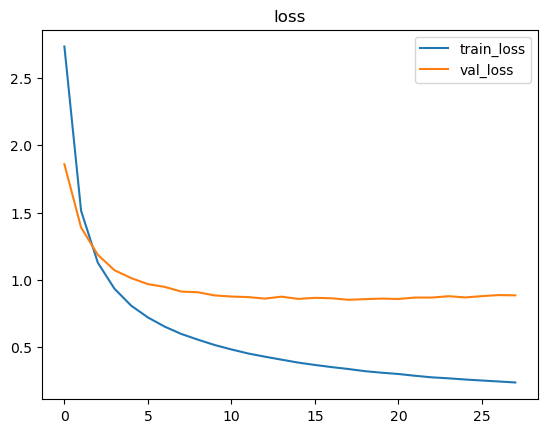

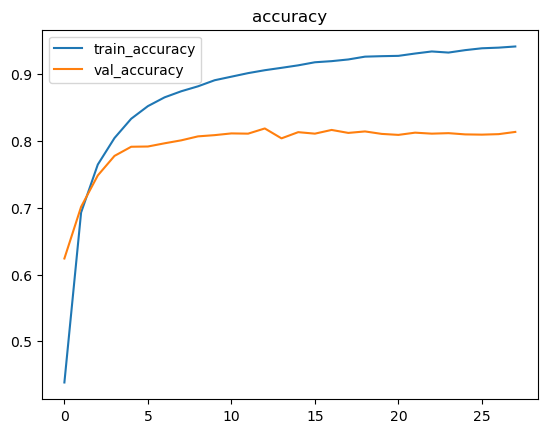

In [10]:
import matplotlib.pyplot as plt

history_df[["train_loss", "val_loss"]].plot(title="loss")
plt.show()
history_df[["train_accuracy", "val_accuracy"]].plot(title="accuracy")
plt.show()